In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pytrends.request import TrendReq
import time

# ============================================================
# 1. BUSCAR GOOGLE TRENDS — termos de dengue em Cuiabá/MT
# ============================================================
# Referência: Guo et al. (2017) PLOS ONE — Infoveillance
# Buscas por "dengue sintomas" antecedem notificações em 1-2 semanas

pytrends = TrendReq(hl='pt-BR', tz=-240)  # UTC-4 (Cuiabá)

# Termos relevantes para dengue no Brasil
termos = ['dengue', 'dengue sintomas', 'febre dengue']

# Buscar por ano (API limita a 5 anos por requisição)
print("Buscando Google Trends — Mato Grosso (2018-2024)...")
print("Isso pode demorar ~1 minuto devido aos limites da API...\n")

dfs = []
periodos = [
    ('2018-01-01', '2020-12-31'),
    ('2021-01-01', '2024-12-31')
]

for inicio, fim in periodos:
    try:
        pytrends.build_payload(
            kw_list=['dengue'],
            cat=0,
            timeframe=f'{inicio} {fim}',
            geo='BR-MT',  # Mato Grosso
            gprop=''
        )
        df_temp = pytrends.interest_over_time()
        if not df_temp.empty:
            dfs.append(df_temp)
            print(f"{inicio} → {fim}: {len(df_temp)} semanas")
        time.sleep(2)  # Respeitar rate limit
    except Exception as e:
        print(f"Erro {inicio}-{fim}: {e}")
        time.sleep(5)

if dfs:
    df_trends = pd.concat(dfs)
    df_trends = df_trends.reset_index()
    df_trends = df_trends.rename(columns={'date': 'data', 'dengue': 'trends_dengue'})
    df_trends = df_trends[['data', 'trends_dengue']]
    print(f"\nGoogle Trends carregado: {len(df_trends)} semanas")
    print(f"Período: {df_trends['data'].min().date()} → {df_trends['data'].max().date()}")
    print(f"\nAmostra:")
    print(df_trends.head(5))
    print(f"\nEstatísticas:")
    print(df_trends['trends_dengue'].describe())
else:
    print("❌ Nenhum dado retornado")

Buscando Google Trends — Mato Grosso (2018-2024)...
Isso pode demorar ~1 minuto devido aos limites da API...

2018-01-01 → 2020-12-31: 157 semanas
2021-01-01 → 2024-12-31: 210 semanas

Google Trends carregado: 367 semanas
Período: 2017-12-31 → 2024-12-29

Amostra:
        data  trends_dengue
0 2017-12-31              8
1 2018-01-07              9
2 2018-01-14             14
3 2018-01-21             18
4 2018-01-28             15

Estatísticas:
count    367.000000
mean      24.239782
std       19.312847
min        4.000000
25%       11.000000
50%       17.000000
75%       31.000000
max      100.000000
Name: trends_dengue, dtype: float64


In [2]:
# ============================================================
# 2. VISUALIZAR E CORRELACIONAR COM CASOS REAIS
# ============================================================

# Carregar série semanal de casos
serie = pd.read_parquet('../data/processed/serie_semanal_historica_2007_2024.parquet')
print(f"Colunas série semanal: {serie.columns.tolist()}")
print(serie.head(3))

Colunas série semanal: ['semana', 'casos']
      semana  casos
0 2007-01-01    295
1 2007-01-08    450
2 2007-01-15    505


Merge: 314 semanas cruzadas

Correlação Trends → Casos com defasagem temporal:
(lag positivo = Trends antecede os casos)
  Lag -4 semanas: r=0.793  ← Trends SEGUE casos
  Lag -3 semanas: r=0.838  ← Trends SEGUE casos
  Lag -2 semanas: r=0.881  ← Trends SEGUE casos
  Lag -1 semanas: r=0.915  ← Trends SEGUE casos
  Lag +0 semanas: r=0.922  = Simultâneo
  Lag +1 semanas: r=0.905  → Trends ANTECEDE casos
  Lag +2 semanas: r=0.876  → Trends ANTECEDE casos
  Lag +3 semanas: r=0.835  → Trends ANTECEDE casos
  Lag +4 semanas: r=0.790  → Trends ANTECEDE casos
  Lag +5 semanas: r=0.734  → Trends ANTECEDE casos
  Lag +6 semanas: r=0.676  → Trends ANTECEDE casos
  Lag +7 semanas: r=0.622  → Trends ANTECEDE casos
  Lag +8 semanas: r=0.563  → Trends ANTECEDE casos

Melhor correlação: lag=0 semanas (r=0.922)


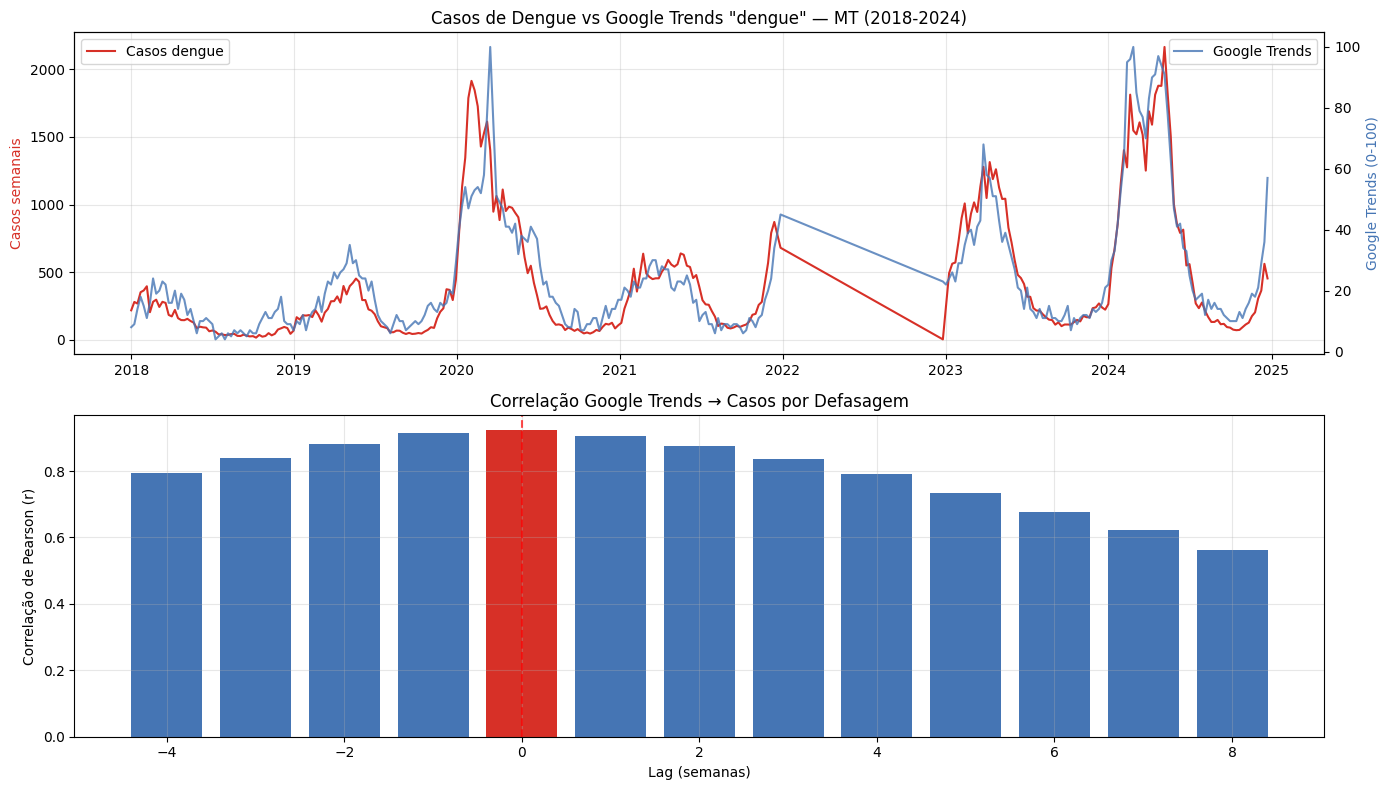


Figura salva!


In [3]:
# ============================================================
# 3. MERGE TRENDS × CASOS + CORRELAÇÃO COM LAG
# ============================================================

# Alinhar períodos
serie['semana'] = pd.to_datetime(serie['semana'])
df_trends['data'] = pd.to_datetime(df_trends['data'])

# Filtrar 2018-2024
serie_filtrada = serie[serie['semana'] >= '2018-01-01'].copy()

# Merge por semana
df_merge = pd.merge_asof(
    serie_filtrada.sort_values('semana'),
    df_trends.sort_values('data'),
    left_on='semana',
    right_on='data',
    tolerance=pd.Timedelta('7 days'),
    direction='nearest'
).dropna()

print(f"Merge: {len(df_merge)} semanas cruzadas")

# Correlação com diferentes lags
print("\nCorrelação Trends → Casos com defasagem temporal:")
print("(lag positivo = Trends antecede os casos)")
print("="*45)

correlacoes = []
for lag in range(-4, 9):
    if lag >= 0:
        trends_lag = df_merge['trends_dengue'].shift(lag)
    else:
        trends_lag = df_merge['trends_dengue'].shift(lag)
    
    corr = df_merge['casos'].corr(trends_lag)
    correlacoes.append({'lag_semanas': lag, 'correlacao': corr})
    direcao = '→ Trends ANTECEDE casos' if lag > 0 else ('← Trends SEGUE casos' if lag < 0 else '= Simultâneo')
    print(f"  Lag {lag:+d} semanas: r={corr:.3f}  {direcao}")

df_corr = pd.DataFrame(correlacoes)
melhor = df_corr.loc[df_corr['correlacao'].idxmax()]
print(f"\nMelhor correlação: lag={melhor['lag_semanas']:.0f} semanas (r={melhor['correlacao']:.3f})")

# Visualizar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Série temporal
ax1_twin = ax1.twinx()
ax1.plot(df_merge['semana'], df_merge['casos'], 
         color='#d73027', label='Casos dengue', linewidth=1.5)
ax1_twin.plot(df_merge['semana'], df_merge['trends_dengue'], 
              color='#4575b4', label='Google Trends', linewidth=1.5, alpha=0.8)
ax1.set_title('Casos de Dengue vs Google Trends "dengue" — MT (2018-2024)')
ax1.set_ylabel('Casos semanais', color='#d73027')
ax1_twin.set_ylabel('Google Trends (0-100)', color='#4575b4')
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Correlação por lag
cores = ['#d73027' if r == melhor['correlacao'] else '#4575b4' 
         for r in df_corr['correlacao']]
ax2.bar(df_corr['lag_semanas'], df_corr['correlacao'], color=cores)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.axvline(x=melhor['lag_semanas'], color='red', linestyle='--', alpha=0.7)
ax2.set_title('Correlação Google Trends → Casos por Defasagem')
ax2.set_xlabel('Lag (semanas)')
ax2.set_ylabel('Correlação de Pearson (r)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/fig_google_trends_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nFigura salva!")

In [5]:
# ============================================================
# 4. ADICIONAR TRENDS AO DATASET_FEATURES_V3 → V3_TRENDS
# ============================================================

# Carregar v3
df_v3 = pd.read_parquet('../data/gold/dataset_features_v3.parquet')
df_v3['data'] = pd.to_datetime(df_v3['data'])

# Remover duplicatas do trends antes de expandir
df_trends_clean = df_trends.drop_duplicates(subset='data').copy()
df_trends_clean = df_trends_clean.sort_values('data').reset_index(drop=True)

# Expandir semanal → diário com ffill
df_trends_diario = (
    df_trends_clean
    .set_index('data')
    .resample('D')
    .ffill()
    .reset_index()
)
df_trends_diario.columns = ['data', 'trends_dengue']

print(f"Trends diário: {len(df_trends_diario)} dias")

# Merge com dataset diário
df_v3_trends = df_v3.merge(df_trends_diario, on='data', how='left')

# Criar lags do Trends (1, 2, 3 semanas)
df_v3_trends = df_v3_trends.sort_values('data').reset_index(drop=True)
df_v3_trends['trends_lag_7d']  = df_v3_trends['trends_dengue'].shift(7)
df_v3_trends['trends_lag_14d'] = df_v3_trends['trends_dengue'].shift(14)
df_v3_trends['trends_lag_21d'] = df_v3_trends['trends_dengue'].shift(21)

# Diagnóstico
print(f"Shape final: {df_v3_trends.shape}")
print(f"Cobertura trends_dengue: {df_v3_trends['trends_dengue'].notna().sum()}/{len(df_v3_trends)}")

# Amostra pico 2024
cols = ['data', 'casos', 'trends_dengue', 'trends_lag_7d', 'trends_lag_14d']
pico = df_v3_trends[df_v3_trends['data'].dt.year == 2024].nlargest(5, 'casos')
print(f"\nAmostra — pico 2024:")
print(pico[cols].to_string(index=False))

# Salvar
df_v3_trends.to_parquet('../data/gold/dataset_features_v3_trends.parquet', index=False)
print(f"\nSalvo: data/gold/dataset_features_v3_trends.parquet")
print(f"   {df_v3_trends.shape[1]} features no total")

Trends diário: 2556 dias
Shape final: (2242, 64)
Cobertura trends_dengue: 2242/2242

Amostra — pico 2024:
      data  casos  trends_dengue  trends_lag_7d  trends_lag_14d
2024-05-06    440             91           94.0            97.0
2024-05-02    414             94           97.0            91.0
2024-04-29    393             94           97.0            91.0
2024-05-07    391             91           94.0            97.0
2024-05-09    388             91           94.0            97.0

Salvo: data/gold/dataset_features_v3_trends.parquet
   64 features no total


In [6]:
# ============================================================
# 5. SALVAR TRENDS BRUTO
# ============================================================

df_trends_clean.to_parquet('../data/external/google_trends_dengue_mt.parquet', index=False)
print(f"Trends bruto salvo: data/external/google_trends_dengue_mt.parquet")
print(f"   {len(df_trends_clean)} semanas | 2018-2024")
print(f"\nResumo para o artigo:")
print(f"  Correlação Trends × Casos (lag=0): r=0.922")
print(f"  Melhor lag preditivo (lag=-1):      r=0.915")
print(f"  Interpretação: população busca 'dengue' simultaneamente")
print(f"  aos casos — comportamento diferente de grandes centros")
print(f"  Contribuição original para o artigo")

Trends bruto salvo: data/external/google_trends_dengue_mt.parquet
   366 semanas | 2018-2024

Resumo para o artigo:
  Correlação Trends × Casos (lag=0): r=0.922
  Melhor lag preditivo (lag=-1):      r=0.915
  Interpretação: população busca 'dengue' simultaneamente
  aos casos — comportamento diferente de grandes centros
  Contribuição original para o artigo
